
# 🛒 Market Basket Analysis

## Internship Project - Codec Technologies

### Project Overview

Market Basket Analysis is a data mining technique used to identify relationships between products purchased by customers.

The main objective of this project is to discover frequently purchased product combinations and generate association rules using the Apriori algorithm.

### Project Objectives

- Analyze customer purchasing patterns.
- Identify frequently purchased products.
- Generate association rules.
- Visualize product relationships.
- Provide useful business insights.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- MLxtend
- JupyterLab

### Author

**Sharad Jain**

B.Tech CSE (Data Science)

In [1]:
print("Market Basket Analysis Project Started")
print("Codec Technologies Internship")
print("Author: Sharad Jain")

Market Basket Analysis Project Started
Codec Technologies Internship
Author: Sharad Jain


## 1. Importing Required Libraries

In this project, we use Python libraries
to perform data analysis and discover
association rules.

- Pandas: Used for data manipulation.
- NumPy: Used for numerical operations.
- Matplotlib: Used for visualization.
- MLxtend: Used for the Apriori algorithm
  and association rule mining.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

print("All libraries imported successfully!")

All libraries imported successfully!



## 2. Loading the Dataset

In this step, we load the Online Retail dataset
using the Pandas library.

The dataset contains retail transaction
information that will be used to identify
frequently purchased products.

### Code Explanation

| Code | Meaning |
|------|---------|
| `import pandas as pd` | Imports Pandas |
| `pd.read_excel()` | Reads the Excel file |
| `df` | Stores the dataset |
| `df.shape` | Shows rows and columns |
| `df.head()` | Displays the first 5 rows |

### Understanding the Code

- **Pandas:** A Python library used for data analysis.
- **DataFrame (df):** A table-like structure that stores data.
- **Shape:** Tells us the number of rows and columns.
- **Head:** Displays the first 5 rows of the dataset.

In [3]:
# Load the Online Retail dataset

import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed
to understand the structure and quality
of the retail transaction dataset.

In this section, we will examine:
- Dataset dimensions
- Column information
- Missing values
- Statistical summary
- Sample records

In [4]:
# Check the number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 541909
Number of Columns: 8


In [5]:
# Display all column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Display statistical summary

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
# Display the first 10 rows

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom



## 4. Understanding Dataset Columns

The Online Retail dataset contains
information about customer transactions.

Each row represents a product entry
within an invoice.

We will use InvoiceNo and Description
to create customer shopping baskets.


## 5. Data Cleaning

Data cleaning is an important step
in preparing transaction data.

The dataset may contain:
- Missing product descriptions
- Cancelled invoices
- Negative quantities
- Invalid transaction records

We will remove unsuitable records
before performing Market Basket Analysis.

In [10]:
# Check missing values in important columns

print("Missing InvoiceNo:", df["InvoiceNo"].isnull().sum())
print("Missing Description:", df["Description"].isnull().sum())

Missing InvoiceNo: 0
Missing Description: 1454


In [11]:
# Remove rows with missing product descriptions

df = df.dropna(subset=["Description"])

print("Shape after removing missing descriptions:", df.shape)

Shape after removing missing descriptions: (540455, 8)


In [12]:
# Remove cancelled transactions

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Shape after removing cancelled transactions:", df.shape)

Shape after removing cancelled transactions: (531167, 8)


In [13]:
# Keep only positive quantities

df = df[df["Quantity"] > 0]

print("Shape after removing invalid quantities:", df.shape)

Shape after removing invalid quantities: (530693, 8)


In [14]:
# Remove missing invoice numbers

df = df.dropna(subset=["InvoiceNo"])

print("Final cleaned dataset shape:", df.shape)

Final cleaned dataset shape: (530693, 8)


## 6. Creating Transaction Baskets

Market Basket Analysis requires
transaction data in basket format.

Each row represents an invoice,
and each column represents a product.

- 1 means the product was purchased.
- 0 means the product was not purchased.

This format is required for
the Apriori algorithm.

In [15]:
# Select required columns

basket_data = df[["InvoiceNo", "Description", "Quantity"]].copy()

basket_data.head()

,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6


In [16]:
# Create transaction basket matrix

basket = basket_data.pivot_table(
    index="InvoiceNo",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Convert quantities into binary values

basket = basket.map(lambda x: 1 if x > 0 else 0)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# Check basket dimensions

print("Number of Transactions:", basket.shape[0])
print("Number of Products:", basket.shape[1])

Number of Transactions: 20136
Number of Products: 4077


## 7. Applying the Apriori Algorithm

The Apriori algorithm is used to identify
frequent itemsets in transaction data.

Frequent itemsets are combinations of
products that appear together frequently.

We will use the support metric to
identify frequently purchased products.

In [19]:
# Generate frequent itemsets using Apriori

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

C:\Users\lenovo\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.023242,(3 STRIPEY MICE FELTCRAFT)
1,0.024037,(4 TRADITIONAL SPINNING TOPS)
2,0.047427,(6 RIBBONS RUSTIC CHARM)
3,0.021702,(60 CAKE CASES DOLLY GIRL DESIGN)
4,0.030691,(60 CAKE CASES VINTAGE CHRISTMAS)


In [20]:
# Convert basket values to Boolean type

basket = basket.astype(bool)

print("Basket converted to Boolean successfully!")

Basket converted to Boolean successfully!


In [21]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.023242,(3 STRIPEY MICE FELTCRAFT)
1,0.024037,(4 TRADITIONAL SPINNING TOPS)
2,0.047427,(6 RIBBONS RUSTIC CHARM)
3,0.021702,(60 CAKE CASES DOLLY GIRL DESIGN)
4,0.030691,(60 CAKE CASES VINTAGE CHRISTMAS)


In [22]:
# Check the number of frequent itemsets

print("Number of Frequent Itemsets:",
      len(frequent_itemsets))

Number of Frequent Itemsets: 375


In [23]:
# Sort itemsets by support

frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(10)

,support,itemsets
273,0.112237,(WHITE HANGING HEART T-LIGHT HOLDER)
102,0.103894,(JUMBO BAG RED RETROSPOT)
197,0.098778,(REGENCY CAKESTAND 3 TIER)
157,0.083731,(PARTY BUNTING)
127,0.077672,(LUNCH BAG RED RETROSPOT)
15,0.072259,(ASSORTED COLOUR BIRD ORNAMENT)
218,0.068782,(SET OF 3 CAKE TINS PANTRY DESIGN )
149,0.065554,(PACK OF 72 RETROSPOT CAKE CASES)
120,0.063220,(LUNCH BAG BLACK SKULL.)
139,0.062028,(NATURAL SLATE HEART CHALKBOARD )


## 8. Visualizing Frequent Itemsets

In this section, we visualize the most
frequently purchased itemsets.

The visualization helps us understand
which products appear most often
in customer transactions.

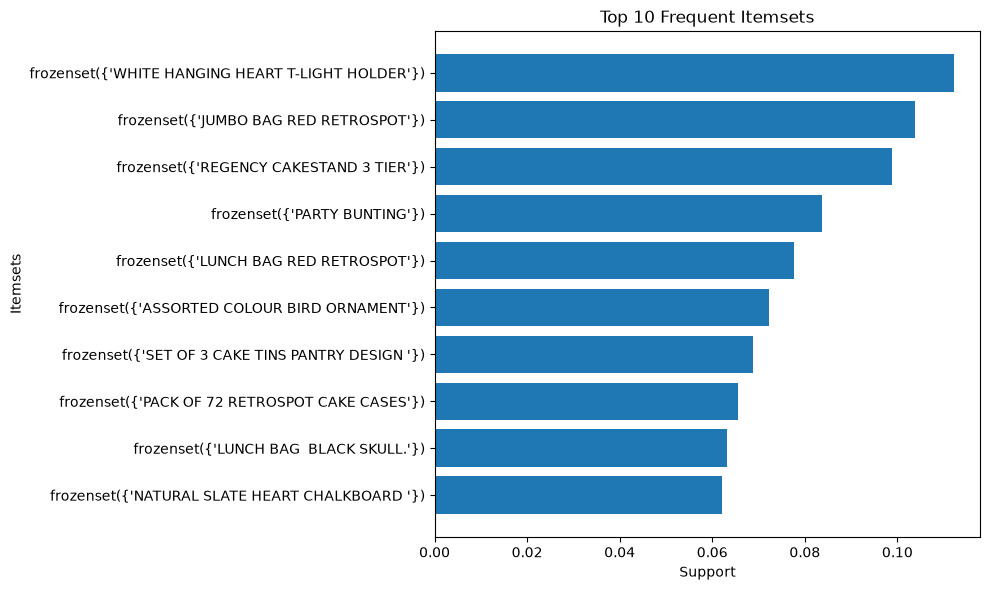

In [24]:
# Visualize top frequent itemsets

top_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top_itemsets)),
    top_itemsets["support"]
)

plt.yticks(
    range(len(top_itemsets)),
    top_itemsets["itemsets"].astype(str)
)

plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.title("Top 10 Frequent Itemsets")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Generating Association Rules

Association rules help us discover
relationships between products.

We will use:
- Support
- Confidence
- Lift

These metrics help evaluate the
strength and usefulness of
product associations.

In [25]:
# Generate association rules

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(PACK OF 72 RETROSPOT CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.065554,0.041120,0.022497,0.343182,8.345784,1.0,0.019801,1.459886,0.941926,0.267257,0.315015,0.445142
1,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.041120,0.065554,0.022497,0.547101,8.345784,1.0,0.019801,2.063256,0.917924,0.267257,0.515329,0.445142
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.038886,0.048669,0.020759,0.533844,10.968864,1.0,0.018866,2.040800,0.945603,0.310781,0.509996,0.480187
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.048669,0.038886,0.020759,0.426531,10.968864,1.0,0.018866,1.675965,0.955328,0.310781,0.403329,0.480187
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.052195,0.048669,0.031784,0.608944,12.511932,1.0,0.029244,2.432722,0.970744,0.460101,0.588938,0.631003


In [26]:
# Display important association rule metrics

rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
0,(PACK OF 72 RETROSPOT CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.022497,0.343182,8.345784
1,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.022497,0.547101,8.345784
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.020759,0.533844,10.968864
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.020759,0.426531,10.968864
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.031784,0.608944,12.511932
5,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.031784,0.653061,12.511932
6,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.023341,0.600255,11.500231
7,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.023341,0.447193,11.500231
8,(CHARLOTTE BAG SUKI DESIGN),(CHARLOTTE BAG PINK POLKADOT),0.020362,0.464853,12.597944
9,(CHARLOTTE BAG PINK POLKADOT),(CHARLOTTE BAG SUKI DESIGN),0.020362,0.551817,12.597944


## 10. Analyzing Association Rules

We will sort the association rules
by lift to identify product
combinations with stronger
observed associations.

In [27]:
# Sort rules by lift

rules_sorted = rules.sort_values(
    by="lift",
    ascending=False
)

rules_sorted[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
136,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.026917,0.705729,18.551648
139,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.026917,0.707572,18.551648
140,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.026917,0.533990,17.950627
135,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.026917,0.904841,17.950627
23,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031436,0.826371,16.393893
24,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031436,0.623645,16.393893
138,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.026917,0.508443,16.173782
137,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.026917,0.856240,16.173782
21,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.027116,0.598028,15.886413
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.027116,0.720317,15.886413


In [28]:
# Filter association rules

useful_rules = rules[
    (rules["confidence"] >= 0.3) &
    (rules["lift"] > 1)
]

print("Number of Useful Rules:", len(useful_rules))

useful_rules.head(10)

Number of Useful Rules: 151


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(PACK OF 72 RETROSPOT CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.065554,0.041120,0.022497,0.343182,8.345784,1.0,0.019801,1.459886,0.941926,0.267257,0.315015,0.445142
1,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.041120,0.065554,0.022497,0.547101,8.345784,1.0,0.019801,2.063256,0.917924,0.267257,0.515329,0.445142
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.038886,0.048669,0.020759,0.533844,10.968864,1.0,0.018866,2.040800,0.945603,0.310781,0.509996,0.480187
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.048669,0.038886,0.020759,0.426531,10.968864,1.0,0.018866,1.675965,0.955328,0.310781,0.403329,0.480187
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.052195,0.048669,0.031784,0.608944,12.511932,1.0,0.029244,2.432722,0.970744,0.460101,0.588938,0.631003
5,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.048669,0.052195,0.031784,0.653061,12.511932,1.0,0.029244,2.731908,0.967146,0.460101,0.633956,0.631003
6,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.038886,0.052195,0.023341,0.600255,11.500231,1.0,0.021312,2.371026,0.949986,0.344575,0.578242,0.523724
7,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.052195,0.038886,0.023341,0.447193,11.500231,1.0,0.021312,1.738608,0.963326,0.344575,0.424827,0.523724
8,(CHARLOTTE BAG SUKI DESIGN),(CHARLOTTE BAG PINK POLKADOT),0.043802,0.036899,0.020362,0.464853,12.597944,1.0,0.018745,1.799693,0.962794,0.337449,0.444350,0.508335
9,(CHARLOTTE BAG PINK POLKADOT),(CHARLOTTE BAG SUKI DESIGN),0.036899,0.043802,0.020362,0.551817,12.597944,1.0,0.018745,2.133499,0.955894,0.337449,0.531286,0.508335


## 11. Visualizing Association Rules

The following visualization compares
confidence and lift values.

This helps us understand how
association rules differ in strength.

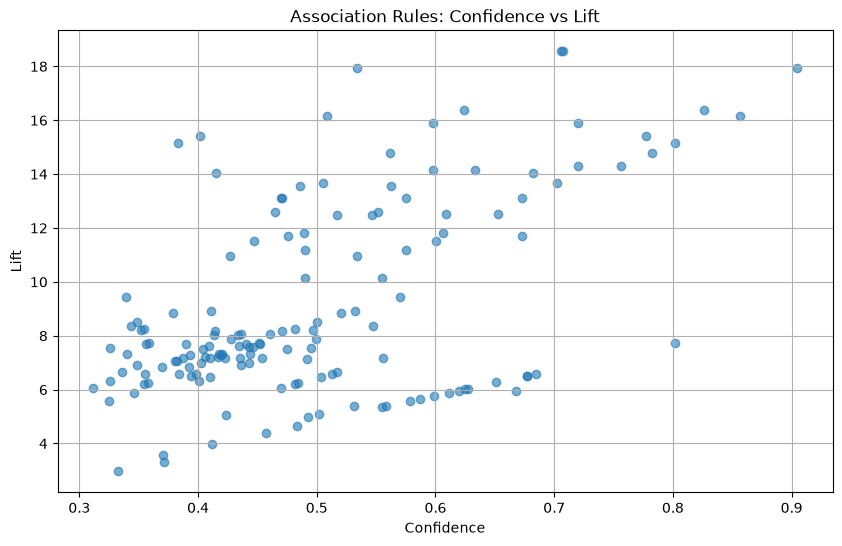

In [30]:
# Visualize confidence and lift

plt.figure(figsize=(10, 6))

plt.scatter(
    useful_rules["confidence"],
    useful_rules["lift"],
    alpha=0.6
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules: Confidence vs Lift")

plt.grid(True)
plt.show()


## 12. Interpreting Association Rules

The generated association rules
help us understand relationships
between products.

We will analyze the rules using
support, confidence, and lift.

These findings can help businesses
understand purchasing patterns and
develop data-driven strategies.

In [31]:
# Display top association rules

top_rules = useful_rules.sort_values(
    by="lift",
    ascending=False
).head(10)

top_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
136,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.026917,0.705729,18.551648
139,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.026917,0.707572,18.551648
140,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.026917,0.533990,17.950627
135,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.026917,0.904841,17.950627
23,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031436,0.826371,16.393893
24,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031436,0.623645,16.393893
138,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.026917,0.508443,16.173782
137,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.026917,0.856240,16.173782
21,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.027116,0.598028,15.886413
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.027116,0.720317,15.886413


In [32]:
# Convert itemsets into readable text

def format_items(items):
    return ", ".join(sorted(items))

business_rules = top_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

business_rules["antecedents"] = (
    business_rules["antecedents"].apply(format_items)
)

business_rules["consequents"] = (
    business_rules["consequents"].apply(format_items)
)

business_rules

,antecedents,consequents,support,confidence,lift
136,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.026917,0.705729,18.551648
139,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.026917,0.707572,18.551648
140,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.026917,0.533990,17.950627
135,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.026917,0.904841,17.950627
23,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031436,0.826371,16.393893
24,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031436,0.623645,16.393893
138,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.026917,0.508443,16.173782
137,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.026917,0.856240,16.173782
21,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.027116,0.598028,15.886413
22,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027116,0.720317,15.886413



## 13. Business Insights

The association rules provide
insights into customer purchasing
patterns.

Potential business applications:

1. Product Bundling:
   Businesses can consider bundling
   products that frequently appear
   together.

2. Cross-Selling:
   Related products can be
   recommended to customers.

3. Store Layout:
   Frequently associated products
   may be considered when planning
   product placement.

4. Inventory Planning:
   Product relationships can support
   purchasing and inventory decisions.

Note:
These are potential applications
of the discovered associations.
Actual business decisions require
further validation.

In [33]:
# Export association rules

business_rules.to_csv(
    "association_rules.csv",
    index=False
)

print("Association rules exported successfully!")

Association rules exported successfully!
